In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

daily_returns = pd.read_csv("../data/processed/daily_returns.csv", index_col=0, parse_dates=True)

tickers = daily_returns.columns.tolist()
n_assets = len(tickers)

trading_days = 252
risk_free_rate = 0.02

daily_returns.head()

,SPY,QQQ,IWM,TLT,GLD,VNQ,EFA
Date,,,,,,,
2015-01-05,-0.018060,-0.014676,-0.013369,0.015708,0.015077,0.005473,-0.023605
2015-01-06,-0.009419,-0.013415,-0.017300,0.018017,0.011399,0.009919,-0.011327
2015-01-07,0.012461,0.012897,0.012315,-0.001975,-0.005891,0.015331,0.011115
2015-01-08,0.017745,0.019149,0.016962,-0.013243,-0.004209,0.003775,0.013530
2015-01-09,-0.008014,-0.006586,-0.009603,0.010953,0.011385,0.000470,-0.004839


In [2]:
def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate=0.02):
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    return portfolio_return, portfolio_volatility, sharpe_ratio

In [3]:
def ledoit_wolf_covariance(returns_window):
    lw = LedoitWolf()
    lw.fit(returns_window)
    cov_matrix = lw.covariance_ * trading_days
    return pd.DataFrame(cov_matrix, index=returns_window.columns, columns=returns_window.columns)

In [4]:
def minimum_variance_weights_sample(returns_window):
    mean_returns = returns_window.mean() * trading_days
    cov_matrix = returns_window.cov() * trading_days
    
    n_assets = returns_window.shape[1]
    initial_weights = np.array([1 / n_assets] * n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
    
    def portfolio_volatility(weights):
        return portfolio_performance(weights, mean_returns, cov_matrix)[1]
    
    result = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

In [5]:
def minimum_variance_weights_lw(returns_window):
    mean_returns = returns_window.mean() * trading_days
    cov_matrix = ledoit_wolf_covariance(returns_window)
    
    n_assets = returns_window.shape[1]
    initial_weights = np.array([1 / n_assets] * n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
    
    def portfolio_volatility(weights):
        return portfolio_performance(weights, mean_returns, cov_matrix)[1]
    
    result = minimize(
        portfolio_volatility,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

In [6]:
def maximum_sharpe_weights_sample(returns_window):
    mean_returns = returns_window.mean() * trading_days
    cov_matrix = returns_window.cov() * trading_days
    
    n_assets = returns_window.shape[1]
    initial_weights = np.array([1 / n_assets] * n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
    
    def negative_sharpe(weights):
        return -portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)[2]
    
    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

In [7]:
def maximum_sharpe_weights_lw(returns_window):
    mean_returns = returns_window.mean() * trading_days
    cov_matrix = ledoit_wolf_covariance(returns_window)
    
    n_assets = returns_window.shape[1]
    initial_weights = np.array([1 / n_assets] * n_assets)
    bounds = tuple((0, 1) for _ in range(n_assets))
    constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
    
    def negative_sharpe(weights):
        return -portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)[2]
    
    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    return result.x

In [8]:
def rolling_backtest_lw_comparison(daily_returns, lookback_window=252, rebalance_window=21):
    strategy_returns = {
        "Min Variance Sample Cov": [],
        "Min Variance Ledoit-Wolf": [],
        "Max Sharpe Sample Cov": [],
        "Max Sharpe Ledoit-Wolf": [],
        "SPY Benchmark": []
    }
    
    dates = []
    
    for start in range(lookback_window, len(daily_returns) - rebalance_window, rebalance_window):
        train_window = daily_returns.iloc[start - lookback_window:start]
        test_window = daily_returns.iloc[start:start + rebalance_window]
        
        weights_dict = {
            "Min Variance Sample Cov": minimum_variance_weights_sample(train_window),
            "Min Variance Ledoit-Wolf": minimum_variance_weights_lw(train_window),
            "Max Sharpe Sample Cov": maximum_sharpe_weights_sample(train_window),
            "Max Sharpe Ledoit-Wolf": maximum_sharpe_weights_lw(train_window)
        }
        
        for strategy, weights in weights_dict.items():
            returns = test_window.dot(weights)
            strategy_returns[strategy].extend(returns.tolist())
        
        strategy_returns["SPY Benchmark"].extend(test_window["SPY"].tolist())
        dates.extend(test_window.index.tolist())
    
    return pd.DataFrame(strategy_returns, index=dates)

In [9]:
lw_backtest_returns = rolling_backtest_lw_comparison(
    daily_returns,
    lookback_window=252,
    rebalance_window=21
)

lw_backtest_returns.head()

,Min Variance Sample Cov,Min Variance Ledoit-Wolf,Max Sharpe Sample Cov,Max Sharpe Ledoit-Wolf,SPY Benchmark
2016-01-05,-0.000240,-0.000240,-0.001736,-0.001736,0.001691
2016-01-06,0.002448,0.002361,-0.009611,-0.009611,-0.012614
2016-01-07,-0.006126,-0.006124,-0.031331,-0.031331,-0.023992
2016-01-08,-0.004806,-0.004908,-0.008110,-0.008110,-0.010977
2016-01-11,-0.006157,-0.006150,0.003078,0.003078,0.000990


In [10]:
lw_backtest_returns.shape

(2499, 5)

In [11]:
lw_backtest_returns.to_csv("../data/processed/ledoit_wolf_backtest_returns.csv")

In [12]:
def performance_table(returns, risk_free_rate=0.02):
    table = pd.DataFrame({
        "Annualized Return": returns.mean() * 252,
        "Annualized Volatility": returns.std() * np.sqrt(252),
        "Sharpe Ratio": (returns.mean() * 252 - risk_free_rate) / (returns.std() * np.sqrt(252))
    })
    return table.T

lw_performance = performance_table(lw_backtest_returns, risk_free_rate)
lw_performance

,Min Variance Sample Cov,Min Variance Ledoit-Wolf,Max Sharpe Sample Cov,Max Sharpe Ledoit-Wolf,SPY Benchmark
Annualized Return,0.071141,0.071915,0.091178,0.090485,0.140472
Annualized Volatility,0.098525,0.098305,0.152204,0.152315,0.181049
Sharpe Ratio,0.519069,0.528106,0.467649,0.462762,0.665409


In [13]:
lw_performance.to_csv("../data/processed/ledoit_wolf_performance.csv")

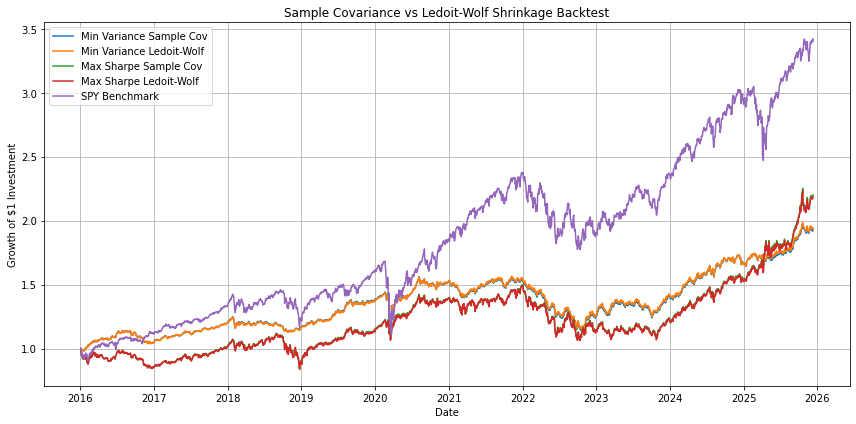

In [14]:
lw_cumulative_returns = (1 + lw_backtest_returns).cumprod()

plt.figure(figsize=(12, 6))

x = lw_cumulative_returns.index.to_numpy()

for column in lw_cumulative_returns.columns:
    y = lw_cumulative_returns[column].to_numpy()
    plt.plot(x, y, label=column)

plt.title("Sample Covariance vs Ledoit-Wolf Shrinkage Backtest")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../figures/ledoit_wolf_backtest_comparison.png", dpi=300)
plt.show()

## Ledoit-Wolf Shrinkage Interpretation

The Ledoit-Wolf covariance estimator was added to reduce estimation error in the covariance matrix used for portfolio optimization. Compared with the sample covariance matrix, the shrinkage estimator provides a more stable covariance estimate by pulling noisy sample estimates toward a structured target.

The results show that Ledoit-Wolf shrinkage slightly improved the minimum variance strategy, increasing its Sharpe ratio from 0.519 to 0.528 while maintaining a similar volatility level. This is consistent with the minimum variance strategy's reliance on covariance estimation.

For the maximum Sharpe strategy, Ledoit-Wolf shrinkage did not improve out-of-sample performance. This suggests that the strategy's instability may be driven not only by covariance estimation error but also by noisy expected return estimates. Overall, the results highlight that robust covariance estimation can improve some risk-based strategies, but it does not eliminate estimation risk in mean-variance optimization.